▶ [현지인] 로드 완료: 25행 | 컬럼: ['기초지자체명', '기초지자체 방문자 수', '기초지자체 방문자 비율']
▶ [외지인] 로드 완료: 25행 | 컬럼: ['기초지자체명', '기초지자체 방문자 수', '기초지자체 방문자 비율']
▶ [외국인] 로드 완료: 25행 | 컬럼: ['지역', '외국인 방문자수']
  → [local] 구 컬럼: '기초지자체명' | 방문 수 컬럼: '기초지자체 방문자 수'
  → [outside] 구 컬럼: '기초지자체명' | 방문 수 컬럼: '기초지자체 방문자 수'
  → [foreign] 구 컬럼: '지역' | 방문 수 컬럼: '외국인 방문자수'

  현지인 + 외지인 방문 수 기준 상위 15개 구
   1위. 강남구      합계:     429,660,546명  (현지인 200,104,454 + 외지인 229,556,092)
   2위. 서초구      합계:     320,667,480명  (현지인 129,220,500 + 외지인 191,446,980)
   3위. 송파구      합계:     295,481,718명  (현지인 160,771,065 + 외지인 134,710,653)
   4위. 영등포구     합계:     224,358,719명  (현지인 103,543,391 + 외지인 120,815,328)
   5위. 마포구      합계:     216,287,155명  (현지인 91,889,140 + 외지인 124,398,015)
   6위. 종로구      합계:     206,023,527명  (현지인 57,104,957 + 외지인 148,918,570)
   7위. 중구       합계:     205,548,137명  (현지인 53,221,357 + 외지인 152,326,780)
   8위. 강서구      합계:     196,999,079명  (현지인 102,842,436 + 외지인 94,156,643)
   9위. 용산구      합계:     177,451,946명  (현지인 58,639,2

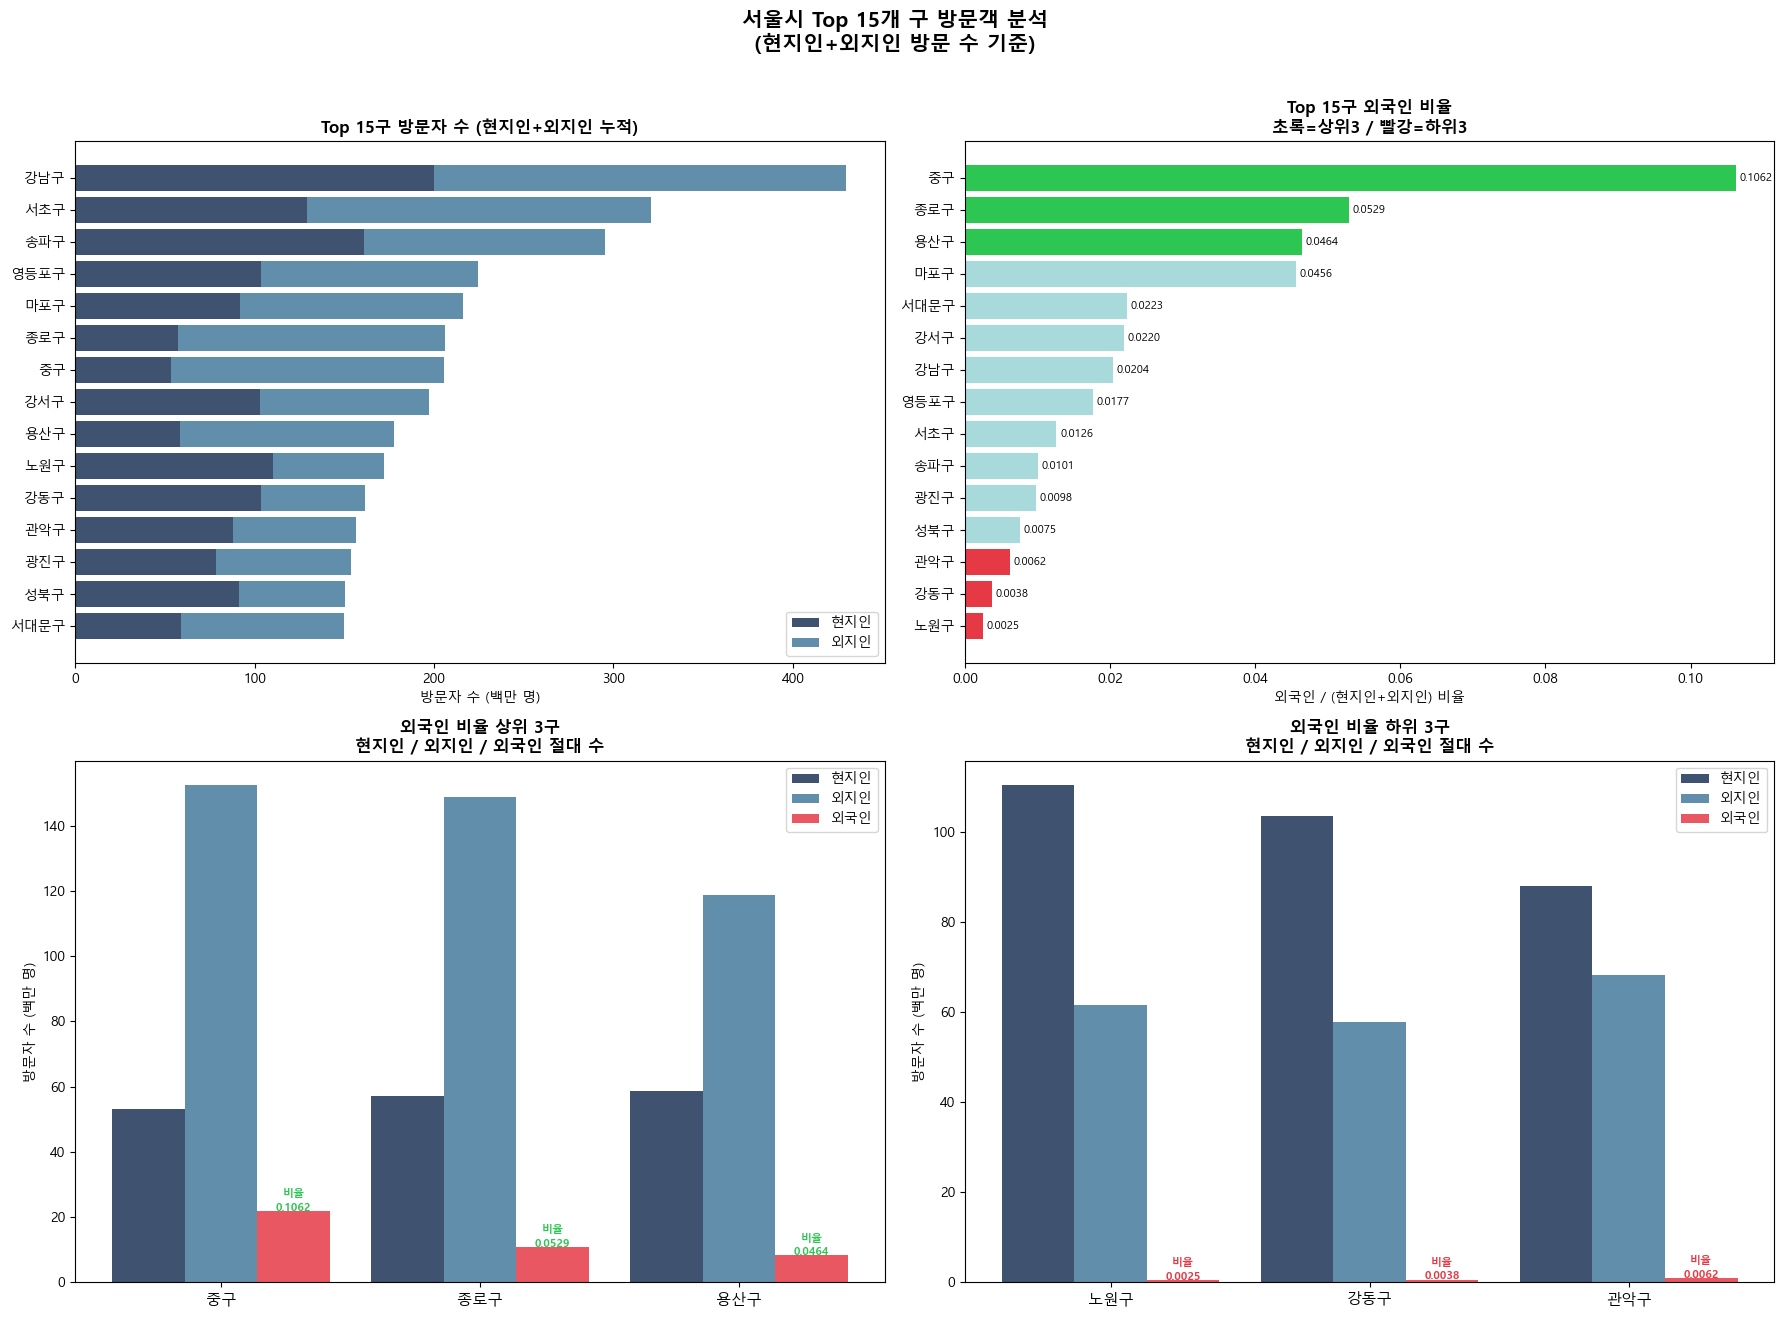


▶ 차트 저장: top15_ratio_analysis.png
▶ 결과 저장: result_top15_ratio.csv


In [1]:
"""
분석 흐름:
  1. 현지인 CSV + 외지인 CSV 병합 → 방문 수 합산 → 상위 15개 구 추출
  2. 현지인 + 외지인 + 외국인 CSV 병합 → Top15 구만 필터
  3. 외국인 / (현지인 + 외지인) 비율 계산 → 상위 3 / 하위 3 출력

CSV 컬럼 구조 (3개 파일 모두 동일):
  A: 기초지자체  B: 기초지자체 방문 수  C: 방문자 비율

파일 경로 설정 (아래 3줄만 수정):
  LOCAL_CSV   = 현지인 CSV 경로
  OUTSIDE_CSV = 외지인 CSV 경로
  FOREIGN_CSV = 외국인 CSV 경로
"""
# 여기서부터 git 정리

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import warnings
warnings.filterwarnings("ignore")


# ══════════════════════════════════════════════════════
# 0. 파일 경로 설정  ← 여기만 수정하세요
# ══════════════════════════════════════════════════════
LOCAL_CSV   = r"C:\Users\USER\OneDrive\바탕 화면\시각화 공모전 데이터\현지인, 외지인, 외국인 방문자\20260511204828_현지인.csv"     # 현지인
OUTSIDE_CSV = r"C:\Users\USER\OneDrive\바탕 화면\시각화 공모전 데이터\현지인, 외지인, 외국인 방문자\20260511204833_외지인.csv"   # 외지인
FOREIGN_CSV = r"C:\Users\USER\OneDrive\바탕 화면\시각화 공모전 데이터\현지인, 외지인, 외국인 방문자\20260511204305_외국인 지역별 방문자 수.csv"   # 외국인


# ══════════════════════════════════════════════════════
# 1. 한글 폰트 설정
# ══════════════════════════════════════════════════════
def set_korean_font():
    candidates = ["Malgun Gothic", "AppleGothic", "NanumGothic", "NanumBarunGothic"]
    available  = {f.name for f in fm.fontManager.ttflist}
    for font in candidates:
        if font in available:
            plt.rcParams["font.family"] = font
            break
    plt.rcParams["axes.unicode_minus"] = False

set_korean_font()


# ══════════════════════════════════════════════════════
# 2. CSV 로드 헬퍼
# ══════════════════════════════════════════════════════
def load_csv(path, label):
    for enc in ["utf-8-sig", "euc-kr", "cp949"]:
        try:
            df = pd.read_csv(path, encoding=enc)
            df.columns = df.columns.str.strip()
            print(f"▶ [{label}] 로드 완료: {len(df)}행 | 컬럼: {list(df.columns)}")
            return df
        except Exception:
            continue
    raise FileNotFoundError(f"{path} 파일을 읽을 수 없습니다.")

df_local   = load_csv(LOCAL_CSV,   "현지인")
df_outside = load_csv(OUTSIDE_CSV, "외지인")
df_foreign = load_csv(FOREIGN_CSV, "외국인")


# ══════════════════════════════════════════════════════
# 3. 컬럼명 자동 탐지 & 정규화
#    - 구 이름 컬럼: "기초지자체" 포함
#    - 방문 수 컬럼: "방문 수" 또는 "방문수" 포함
# ══════════════════════════════════════════════════════
# ── 컬럼명 직접 지정 ──────────────────────────────────
GU_COL  = "기초지자체명"          # 구 이름 컬럼
CNT_COL = "기초지자체 방문자 수"   # 방문자 수 컬럼
# ──────────────────────────────────────────────────────

def detect_cols(df, label=""):
    # 직접 지정된 컬럼이 있으면 우선 사용
    gu_col  = GU_COL  if GU_COL  in df.columns else None
    cnt_col = CNT_COL if CNT_COL in df.columns else None

    # 없으면 키워드로 자동 탐지
    if gu_col is None:
        candidates = [c for c in df.columns if "기초지자체" in c and "방문" not in c and "비율" not in c]
        gu_col = candidates[0] if candidates else None
    if cnt_col is None:
        candidates = [c for c in df.columns if "방문" in c and "비율" not in c]
        cnt_col = candidates[0] if candidates else None

    # 그래도 없으면 타입 기반 폴백
    if gu_col is None:
        gu_col = next((c for c in df.columns if df[c].dtype == object), None)
    if cnt_col is None:
        cnt_col = next((c for c in df.columns if pd.api.types.is_numeric_dtype(df[c])), None)

    if not gu_col or not cnt_col:
        raise ValueError(f"[{label}] 컬럼 탐지 실패. 전체 컬럼: {list(df.columns)}")

    print(f"  → [{label}] 구 컬럼: '{gu_col}' | 방문 수 컬럼: '{cnt_col}'")
    return gu_col, cnt_col

def normalize(df, label):
    gu_col, cnt_col = detect_cols(df, label)
    df = df[[gu_col, cnt_col]].copy()
    df.columns = ["gu", f"count_{label}"]
    df[f"count_{label}"] = pd.to_numeric(df[f"count_{label}"], errors="coerce").fillna(0)
    return df

df_l = normalize(df_local,   "local")
df_o = normalize(df_outside, "outside")
df_f = normalize(df_foreign, "foreign")


# ══════════════════════════════════════════════════════
# 4. 현지인 + 외지인 병합 → 방문 합산 → 상위 15개 구
# ══════════════════════════════════════════════════════
df_lo = df_l.merge(df_o, on="gu", how="outer").fillna(0)
df_lo["count_lo"] = df_lo["count_local"] + df_lo["count_outside"]

top15_list = (
    df_lo.nlargest(15, "count_lo")["gu"].tolist()
)

print(f"\n{'='*55}")
print(f"  현지인 + 외지인 방문 수 기준 상위 15개 구")
print(f"{'='*55}")
top15_df = df_lo[df_lo["gu"].isin(top15_list)].sort_values("count_lo", ascending=False).reset_index(drop=True)
for i, row in top15_df.iterrows():
    print(f"  {i+1:>2}위. {row['gu']:<7}  합계: {row['count_lo']:>15,.0f}명  "
          f"(현지인 {row['count_local']:,.0f} + 외지인 {row['count_outside']:,.0f})")


# ══════════════════════════════════════════════════════
# 5. 3개 데이터 병합 → Top15 필터 → 비율 계산
#    비율 = 외국인 / (현지인 + 외지인)
# ══════════════════════════════════════════════════════
df_all = df_lo.merge(df_f, on="gu", how="outer").fillna(0)
df_top15 = df_all[df_all["gu"].isin(top15_list)].copy()

df_top15["ratio"] = df_top15["count_foreign"] / df_top15["count_lo"]

top3    = df_top15.nlargest(3,  "ratio")
bottom3 = df_top15.nsmallest(3, "ratio")

print(f"\n{'='*60}")
print(f"  ▲ [Top15 중] 외국인 비율 높은 구 (외국인 / 현지인+외지인)")
print(f"{'='*60}")
for rank, (_, row) in enumerate(top3.iterrows(), 1):
    print(f"  {rank}위. {row['gu']:<7}  외국인: {row['count_foreign']:>12,.0f}명  "
          f"현지인+외지인: {row['count_lo']:>15,.0f}명  비율: {row['ratio']:.4f}")

print(f"\n{'='*60}")
print(f"  ▼ [Top15 중] 외국인 비율 낮은 구 (외국인 / 현지인+외지인)")
print(f"{'='*60}")
for rank, (_, row) in enumerate(bottom3.iterrows(), 1):
    print(f"  {rank}위. {row['gu']:<7}  외국인: {row['count_foreign']:>12,.0f}명  "
          f"현지인+외지인: {row['count_lo']:>15,.0f}명  비율: {row['ratio']:.4f}")


# ══════════════════════════════════════════════════════
# 6. 시각화 — 2×2 차트
# ══════════════════════════════════════════════════════
COLOR_LOCAL   = "#1D3557"
COLOR_OUTSIDE = "#457B9D"
COLOR_FOREIGN = "#E63946"
COLOR_TOP     = "#2DC653"
COLOR_DEFAULT = "#A8DADC"

fig, axes = plt.subplots(2, 2, figsize=(18, 13))
fig.suptitle("서울시 Top 15개 구 방문객 분석\n(현지인+외지인 방문 수 기준)",
             fontsize=15, fontweight="bold", y=1.01)

# ── (1) Top15 구 현지인+외지인 합산 방문 수 ──
ax1 = axes[0][0]
top15_sorted = top15_df.sort_values("count_lo")
ax1.barh(top15_sorted["gu"], top15_sorted["count_local"] / 1e6,
         color=COLOR_LOCAL, alpha=0.85, label="현지인")
ax1.barh(top15_sorted["gu"], top15_sorted["count_outside"] / 1e6,
         left=top15_sorted["count_local"] / 1e6,
         color=COLOR_OUTSIDE, alpha=0.85, label="외지인")
ax1.set_xlabel("방문자 수 (백만 명)")
ax1.set_title("Top 15구 방문자 수 (현지인+외지인 누적)", fontweight="bold")
ax1.legend()

# ── (2) Top15 구 외국인 비율 전체 ──
ax2 = axes[0][1]
df_ratio_sorted = df_top15.sort_values("ratio")
colors2 = []
for gu in df_ratio_sorted["gu"]:
    if gu in top3["gu"].values:
        colors2.append(COLOR_TOP)
    elif gu in bottom3["gu"].values:
        colors2.append(COLOR_FOREIGN)
    else:
        colors2.append(COLOR_DEFAULT)
bars2 = ax2.barh(df_ratio_sorted["gu"], df_ratio_sorted["ratio"], color=colors2)
ax2.set_xlabel("외국인 / (현지인+외지인) 비율")
ax2.set_title("Top 15구 외국인 비율\n초록=상위3 / 빨강=하위3", fontweight="bold")
for bar, val in zip(bars2, df_ratio_sorted["ratio"]):
    ax2.text(bar.get_width() + 0.0005, bar.get_y() + bar.get_height()/2,
             f"{val:.4f}", va="center", fontsize=8)

# ── (3) 외국인 비율 상위 3곳 ──
ax3 = axes[1][0]
x = list(range(len(top3)))
w = 0.28
top3_reset = top3.reset_index(drop=True)
ax3.bar([i - w for i in x], top3_reset["count_local"]  / 1e6, w, label="현지인", color=COLOR_LOCAL,   alpha=0.85)
ax3.bar([i      for i in x], top3_reset["count_outside"]/ 1e6, w, label="외지인", color=COLOR_OUTSIDE, alpha=0.85)
ax3.bar([i + w  for i in x], top3_reset["count_foreign"]/ 1e6, w, label="외국인", color=COLOR_FOREIGN, alpha=0.85)
ax3.set_xticks(x)
ax3.set_xticklabels(top3_reset["gu"], fontsize=11)
ax3.set_ylabel("방문자 수 (백만 명)")
ax3.set_title("외국인 비율 상위 3구\n현지인 / 외지인 / 외국인 절대 수", fontweight="bold")
ax3.legend()
for i, row in top3_reset.iterrows():
    ax3.text(i + w, row["count_foreign"] / 1e6 + 0.01,
             f"비율\n{row['ratio']:.4f}", ha="center", fontsize=8,
             color=COLOR_TOP, fontweight="bold")

# ── (4) 외국인 비율 하위 3곳 ──
ax4 = axes[1][1]
bottom3_reset = bottom3.reset_index(drop=True)
ax4.bar([i - w for i in x], bottom3_reset["count_local"]  / 1e6, w, label="현지인", color=COLOR_LOCAL,   alpha=0.85)
ax4.bar([i      for i in x], bottom3_reset["count_outside"]/ 1e6, w, label="외지인", color=COLOR_OUTSIDE, alpha=0.85)
ax4.bar([i + w  for i in x], bottom3_reset["count_foreign"]/ 1e6, w, label="외국인", color=COLOR_FOREIGN, alpha=0.85)
ax4.set_xticks(x)
ax4.set_xticklabels(bottom3_reset["gu"], fontsize=11)
ax4.set_ylabel("방문자 수 (백만 명)")
ax4.set_title("외국인 비율 하위 3구\n현지인 / 외지인 / 외국인 절대 수", fontweight="bold")
ax4.legend()
for i, row in bottom3_reset.iterrows():
    ax4.text(i + w, row["count_foreign"] / 1e6 + 0.01,
             f"비율\n{row['ratio']:.4f}", ha="center", fontsize=8,
             color=COLOR_FOREIGN, fontweight="bold")

plt.tight_layout()
CHART = "top15_ratio_analysis.png"
plt.savefig(CHART, dpi=150, bbox_inches="tight")
plt.show()
print(f"\n▶ 차트 저장: {CHART}")

# 결과 CSV 저장
df_top15.sort_values("ratio", ascending=False).to_csv(
    "result_top15_ratio.csv", index=False, encoding="utf-8-sig"
)
print("▶ 결과 저장: result_top15_ratio.csv")

▶ [현지인] 로드 완료: 25행 | 컬럼: ['기초지자체명', '기초지자체 방문자 수', '기초지자체 방문자 비율']
▶ [외지인] 로드 완료: 25행 | 컬럼: ['기초지자체명', '기초지자체 방문자 수', '기초지자체 방문자 비율']
▶ [외국인] 로드 완료: 25행 | 컬럼: ['지역', '외국인 방문자수']
  → [local] 구 컬럼: '기초지자체명' | 방문 수 컬럼: '기초지자체 방문자 수'
  → [outside] 구 컬럼: '기초지자체명' | 방문 수 컬럼: '기초지자체 방문자 수'
  → [foreign] 구 컬럼: '지역' | 방문 수 컬럼: '외국인 방문자수'

  현지인 + 외지인 방문 수 기준 상위 15개 구
   1위. 강남구      합계:     429,660,546명  (현지인 200,104,454 + 외지인 229,556,092)
   2위. 서초구      합계:     320,667,480명  (현지인 129,220,500 + 외지인 191,446,980)
   3위. 송파구      합계:     295,481,718명  (현지인 160,771,065 + 외지인 134,710,653)
   4위. 영등포구     합계:     224,358,719명  (현지인 103,543,391 + 외지인 120,815,328)
   5위. 마포구      합계:     216,287,155명  (현지인 91,889,140 + 외지인 124,398,015)
   6위. 종로구      합계:     206,023,527명  (현지인 57,104,957 + 외지인 148,918,570)
   7위. 중구       합계:     205,548,137명  (현지인 53,221,357 + 외지인 152,326,780)
   8위. 강서구      합계:     196,999,079명  (현지인 102,842,436 + 외지인 94,156,643)
   9위. 용산구      합계:     177,451,946명  (현지인 58,639,2

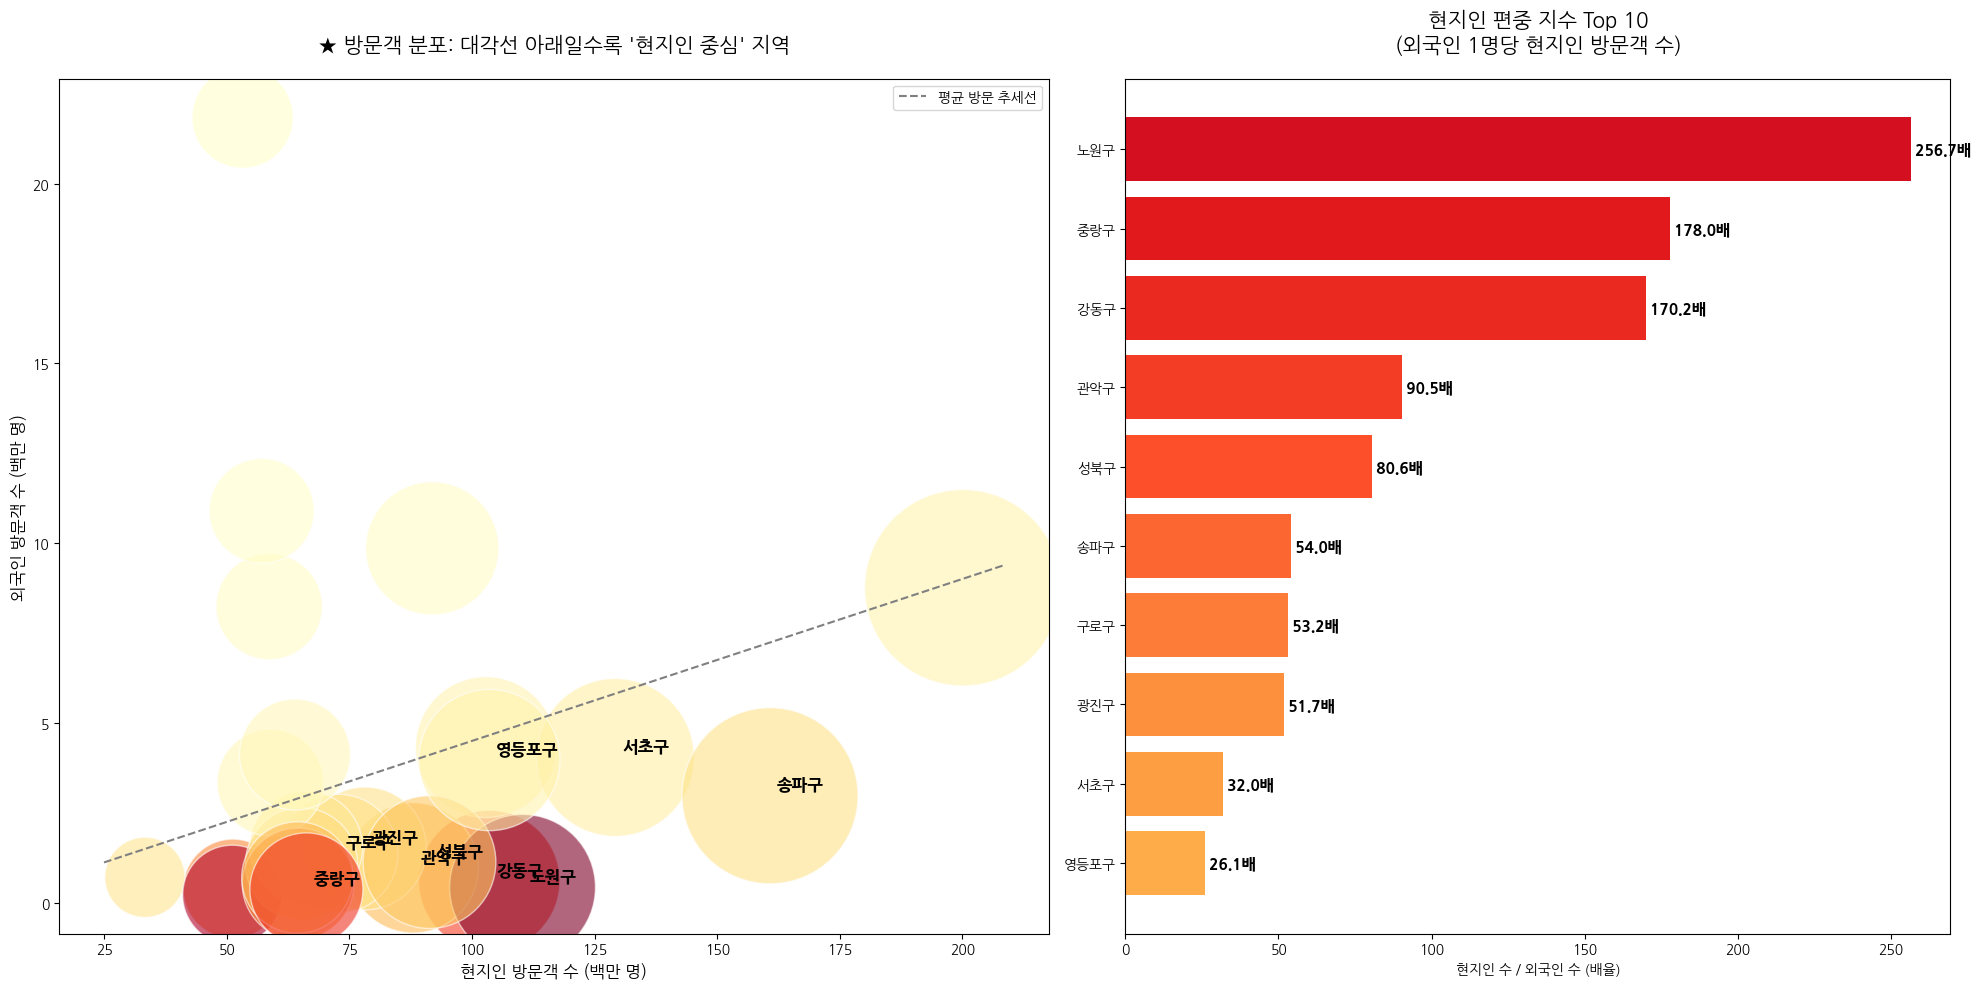

▶ '현지인 편중도' 분석 완료. 대각선 아래에 위치한 구들이 공모전 전략지입니다.


In [2]:
"""
분석 흐름:
  1. 현지인 CSV + 외지인 CSV 병합 → 방문 수 합산 → 상위 15개 구 추출
  2. 현지인 + 외지인 + 외국인 CSV 병합 → Top15 구만 필터
  3. 외국인 / (현지인 + 외지인) 비율 계산 → 상위 3 / 하위 3 출력

CSV 컬럼 구조 (3개 파일 모두 동일):
  A: 기초지자체  B: 기초지자체 방문 수  C: 방문자 비율

파일 경로 설정 (아래 3줄만 수정):
  LOCAL_CSV   = 현지인 CSV 경로
  OUTSIDE_CSV = 외지인 CSV 경로
  FOREIGN_CSV = 외국인 CSV 경로
"""
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import warnings
warnings.filterwarnings("ignore")


# ══════════════════════════════════════════════════════
# 0. 파일 경로 설정  ← 여기만 수정하세요
# ══════════════════════════════════════════════════════
LOCAL_CSV   = r"C:\Users\USER\OneDrive\바탕 화면\시각화 공모전 데이터\현지인, 외지인, 외국인 방문자\20260511204828_현지인.csv"     # 현지인
OUTSIDE_CSV = r"C:\Users\USER\OneDrive\바탕 화면\시각화 공모전 데이터\현지인, 외지인, 외국인 방문자\20260511204833_외지인.csv"   # 외지인
FOREIGN_CSV = r"C:\Users\USER\OneDrive\바탕 화면\시각화 공모전 데이터\현지인, 외지인, 외국인 방문자\20260511204305_외국인 지역별 방문자 수.csv"   # 외국인


# ══════════════════════════════════════════════════════
# 1. 한글 폰트 설정
# ══════════════════════════════════════════════════════
plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams["axes.unicode_minus"] = False


# ══════════════════════════════════════════════════════
# 2. CSV 로드 헬퍼
# ══════════════════════════════════════════════════════
def load_csv(path, label):
    for enc in ["utf-8-sig", "euc-kr", "cp949"]:
        try:
            df = pd.read_csv(path, encoding=enc)
            df.columns = df.columns.str.strip()
            print(f"▶ [{label}] 로드 완료: {len(df)}행 | 컬럼: {list(df.columns)}")
            return df
        except Exception:
            continue
    raise FileNotFoundError(f"{path} 파일을 읽을 수 없습니다.")

df_local   = load_csv(LOCAL_CSV,   "현지인")
df_outside = load_csv(OUTSIDE_CSV, "외지인")
df_foreign = load_csv(FOREIGN_CSV, "외국인")


# ══════════════════════════════════════════════════════
# 3. 컬럼명 자동 탐지 & 정규화
#    - 구 이름 컬럼: "기초지자체" 포함
#    - 방문 수 컬럼: "방문 수" 또는 "방문수" 포함
# ══════════════════════════════════════════════════════
# ── 컬럼명 직접 지정 ──────────────────────────────────
GU_COL  = "기초지자체명"          # 구 이름 컬럼
CNT_COL = "기초지자체 방문자 수"   # 방문자 수 컬럼
# ──────────────────────────────────────────────────────

def detect_cols(df, label=""):
    # 직접 지정된 컬럼이 있으면 우선 사용
    gu_col  = GU_COL  if GU_COL  in df.columns else None
    cnt_col = CNT_COL if CNT_COL in df.columns else None

    # 없으면 키워드로 자동 탐지
    if gu_col is None:
        candidates = [c for c in df.columns if "기초지자체" in c and "방문" not in c and "비율" not in c]
        gu_col = candidates[0] if candidates else None
    if cnt_col is None:
        candidates = [c for c in df.columns if "방문" in c and "비율" not in c]
        cnt_col = candidates[0] if candidates else None

    # 그래도 없으면 타입 기반 폴백
    if gu_col is None:
        gu_col = next((c for c in df.columns if df[c].dtype == object), None)
    if cnt_col is None:
        cnt_col = next((c for c in df.columns if pd.api.types.is_numeric_dtype(df[c])), None)

    if not gu_col or not cnt_col:
        raise ValueError(f"[{label}] 컬럼 탐지 실패. 전체 컬럼: {list(df.columns)}")

    print(f"  → [{label}] 구 컬럼: '{gu_col}' | 방문 수 컬럼: '{cnt_col}'")
    return gu_col, cnt_col

def normalize(df, label):
    gu_col, cnt_col = detect_cols(df, label)
    df = df[[gu_col, cnt_col]].copy()
    df.columns = ["gu", f"count_{label}"]
    df[f"count_{label}"] = pd.to_numeric(df[f"count_{label}"], errors="coerce").fillna(0)
    return df

df_l = normalize(df_local,   "local")
df_o = normalize(df_outside, "outside")
df_f = normalize(df_foreign, "foreign")


# ══════════════════════════════════════════════════════
# 4. 현지인 + 외지인 병합 → 방문 합산 → 상위 15개 구
# ══════════════════════════════════════════════════════
df_lo = df_l.merge(df_o, on="gu", how="outer").fillna(0)
df_lo["count_lo"] = df_lo["count_local"] + df_lo["count_outside"]

top15_list = (
    df_lo.nlargest(15, "count_lo")["gu"].tolist()
)

print(f"\n{'='*55}")
print(f"  현지인 + 외지인 방문 수 기준 상위 15개 구")
print(f"{'='*55}")
top15_df = df_lo[df_lo["gu"].isin(top15_list)].sort_values("count_lo", ascending=False).reset_index(drop=True)
for i, row in top15_df.iterrows():
    print(f"  {i+1:>2}위. {row['gu']:<7}  합계: {row['count_lo']:>15,.0f}명  "
          f"(현지인 {row['count_local']:,.0f} + 외지인 {row['count_outside']:,.0f})")


# ══════════════════════════════════════════════════════
# 5. 3개 데이터 병합 → Top15 필터 → 비율 계산
#    비율 = 외국인 / (현지인 + 외지인)
# ══════════════════════════════════════════════════════
df_all = df_lo.merge(df_f, on="gu", how="outer").fillna(0)
# '현지인 대비 외국인 방문 비율'의 역수를 취하여 '현지인 편중도' 계산
# 현지인 방문이 100명일 때 외국인이 몇 명이나 오는지 계산 (낮을수록 현지인 전용 명소)
df_all['local_preference'] = df_all['count_local'] / (df_all['count_foreign'] + 1) # 0나누기 방지

# 분석 대상: 현지인 방문객이 최소 상위 50% 이상인 구 중에서 선별 (유의미한 장소 선정)
min_local_threshold = df_all['count_local'].median()
df_filtered = df_all[df_all['count_local'] >= min_local_threshold].copy()

# '현지인 편중도' 상위 10개 추출
target_spots = df_filtered.nlargest(10, 'local_preference')

df_top15 = df_all[df_all["gu"].isin(top15_list)].copy()

df_top15["ratio"] = df_top15["count_foreign"] / df_top15["count_lo"]

top3    = df_top15.nlargest(3,  "ratio")
bottom3 = df_top15.nsmallest(3, "ratio")

print(f"\n{'='*60}")
print(f"  ▲ [Top15 중] 외국인 비율 높은 구 (외국인 / 현지인+외지인)")
print(f"{'='*60}")
for rank, (_, row) in enumerate(top3.iterrows(), 1):
    print(f"  {rank}위. {row['gu']:<7}  외국인: {row['count_foreign']:>12,.0f}명  "
          f"현지인+외지인: {row['count_lo']:>15,.0f}명  비율: {row['ratio']:.4f}")

print(f"\n{'='*60}")
print(f"  ▼ [Top15 중] 외국인 비율 낮은 구 (외국인 / 현지인+외지인)")
print(f"{'='*60}")
for rank, (_, row) in enumerate(bottom3.iterrows(), 1):
    print(f"  {rank}위. {row['gu']:<7}  외국인: {row['count_foreign']:>12,.0f}명  "
          f"현지인+외지인: {row['count_lo']:>15,.0f}명  비율: {row['ratio']:.4f}")


# ══════════════════════════════════════════════════════
# 3. 시각화 - "현지인만 아는 핫플레이스 분석"
# ══════════════════════════════════════════════════════
fig = plt.figure(figsize=(20, 10))
gs = fig.add_gridspec(1, 2, width_ratios=[1.2, 1])

# --- [왼쪽] 산점도 분석: 현지인 vs 외국인 ---
ax1 = fig.add_subplot(gs[0])
scatter = ax1.scatter(df_all['count_local']/1e6, df_all['count_foreign']/1e6, 
                     s=df_all['count_local']/1e4, c=df_all['local_preference'], 
                     cmap='YlOrRd', alpha=0.6, edgecolors='w')

# 대각선 기준선 (평균적인 방문 추세)
x_vals = np.array(ax1.get_xlim())
ax1.plot(x_vals, x_vals * (df_all['count_foreign'].sum()/df_all['count_local'].sum()), 
         ls="--", color="gray", label="평균 방문 추세선")

# 주요 지역 텍스트 라벨링 (현지인 편중도가 높은 곳들)
for i, row in target_spots.iterrows():
    ax1.annotate(row['gu'], (row['count_local']/1e6, row['count_foreign']/1e6),
                 xytext=(5, 5), textcoords='offset points', fontsize=12, fontweight='bold')

ax1.set_xlabel("현지인 방문객 수 (백만 명)", fontsize=12)
ax1.set_ylabel("외국인 방문객 수 (백만 명)", fontsize=12)
ax1.set_title("★ 방문객 분포: 대각선 아래일수록 '현지인 중심' 지역", fontsize=15, pad=20)
ax1.legend()

# --- [오른쪽] 현지인 편중도 지수 (Gap Index) ---
ax2 = fig.add_subplot(gs[1])
colors = plt.cm.get_cmap('YlOrRd')(np.linspace(0.4, 0.8, 10))
bars = ax2.barh(target_spots['gu'][::-1], target_spots['local_preference'][::-1], color=colors)

ax2.set_title("현지인 편중 지수 Top 10\n(외국인 1명당 현지인 방문객 수)", fontsize=15, pad=20)
ax2.set_xlabel("현지인 수 / 외국인 수 (배율)")

# 값 표시
for bar in bars:
    ax2.text(bar.get_width(), bar.get_y() + bar.get_height()/2, 
             f' {bar.get_width():.1f}배', va='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig("local_hidden_gems.png", dpi=150)
plt.show()

print("▶ '현지인 편중도' 분석 완료. 대각선 아래에 위치한 구들이 공모전 전략지입니다.")